In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import platform
from sklearn.preprocessing import LabelEncoder, StandardScaler
# 设置中文字体，兼容不同操作系统
ios = platform.system()
if ios == 'Darwin':  # macOS
    matplotlib.rc('font', family='Arial Unicode MS')
elif ios == 'Windows':
    matplotlib.rc('font', family='SimHei')
else:
    matplotlib.rc('font', family='DejaVu Sans')
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

In [5]:

# 1. 读取数据
df = pd.read_csv('train.csv')

# 2. 基本信息
def basic_info(df):
    print('数据集基本信息:')
    print(df.info())
    print('\n前5行:')
    print(df.head())
    print('\n描述统计:')
    print(df.describe(include='all'))
    print('\n缺失值统计:')
    print(df.isnull().sum())

basic_info(df)

数据集基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139930 entries, 0 to 139929
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       139930 non-null  int64  
 1   country                  139930 non-null  object 
 2   property_type            139930 non-null  object 
 3   furnishing_status        139930 non-null  object 
 4   property_size_sqft       139930 non-null  int64  
 5   price                    139930 non-null  int64  
 6   constructed_year         139930 non-null  int64  
 7   previous_owners          139930 non-null  int64  
 8   rooms                    139930 non-null  int64  
 9   bathrooms                139930 non-null  int64  
 10  garage                   139930 non-null  int64  
 11  garden                   139930 non-null  int64  
 12  crime_cases_reported     139930 non-null  int64  
 13  legal_cases_on_property  139930 non-null  int64  


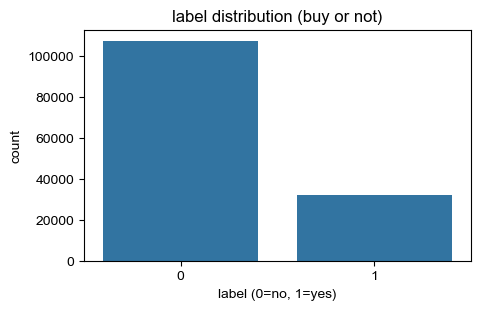

label distribution:
label
0    107610
1     32320
Name: count, dtype: int64


In [13]:
# 3. 标签分布
plt.figure(figsize=(5,3))
sns.countplot(x='label', data=df)
plt.title('label distribution (buy or not)')
plt.xlabel('label (0=no, 1=yes)')
plt.ylabel('count')
plt.show()
print('label distribution:')
print(df['label'].value_counts())

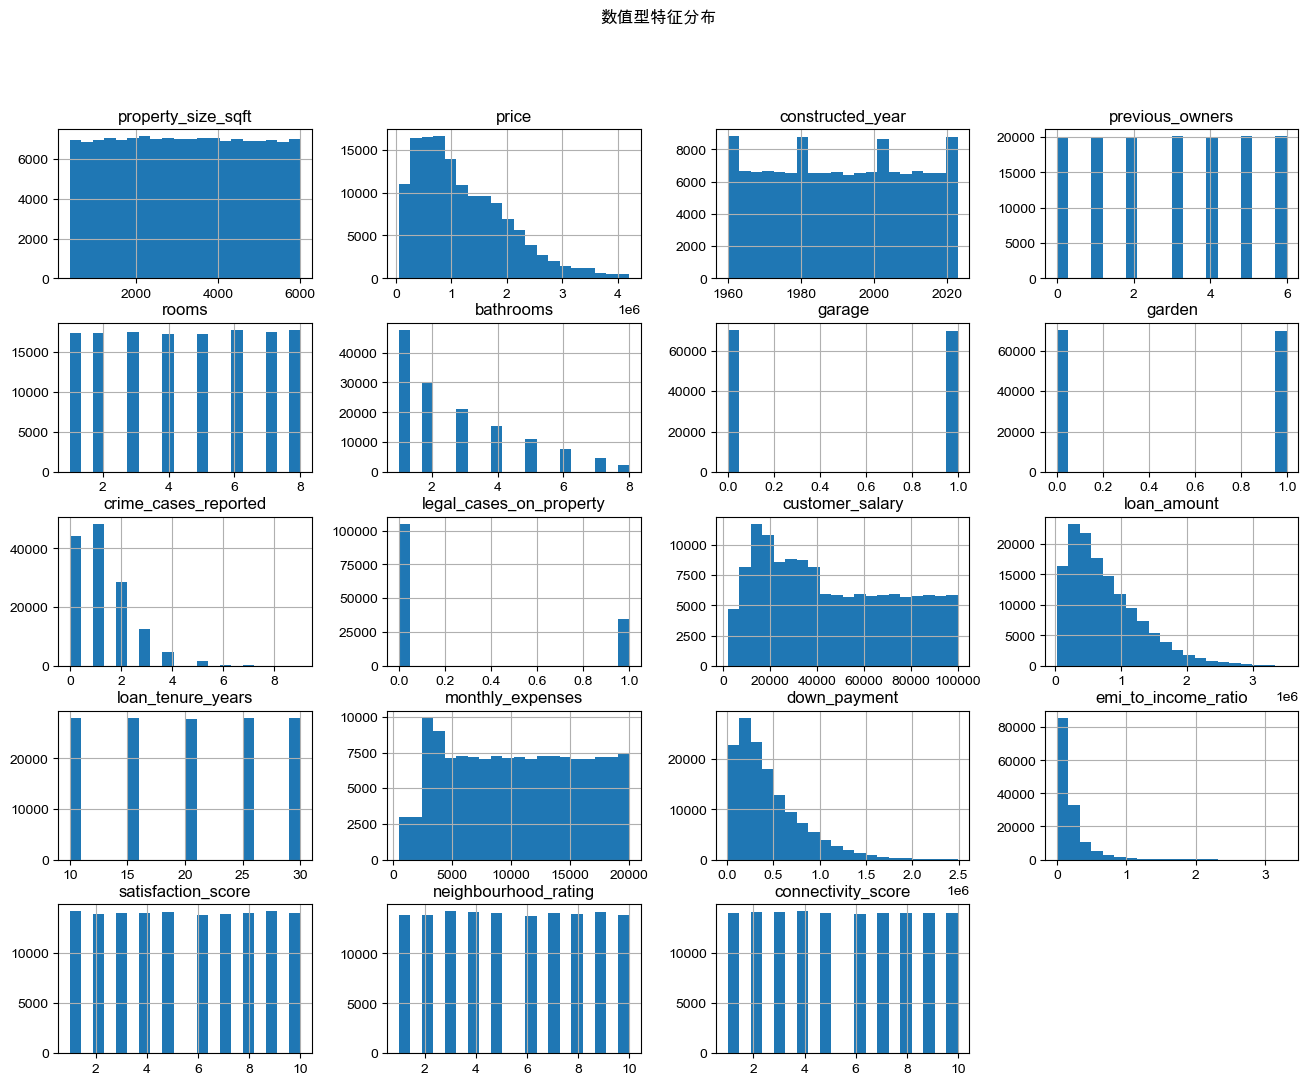

In [15]:
# 4. 数值型特征分布
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [col for col in num_cols if col not in ['id', 'label']]
df[num_cols].hist(figsize=(16, 12), bins=20)
plt.suptitle('数值型特征分布')
plt.show()

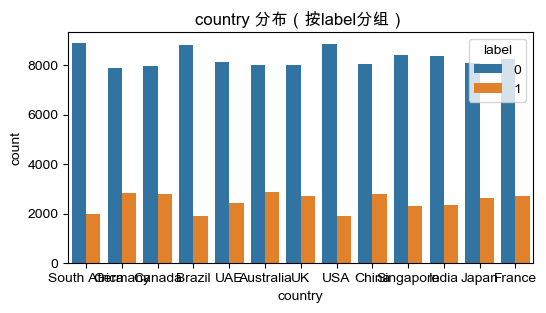

country
France          10946
Australia       10884
South Africa    10869
China           10850
Brazil          10743
USA             10739
India           10738
UK              10736
Canada          10735
Japan           10734
Germany         10726
Singapore       10699
UAE             10531
Name: count, dtype: int64


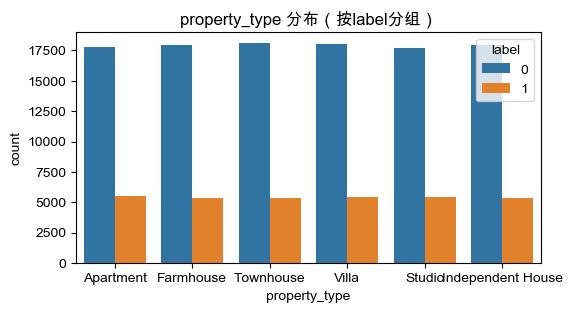

property_type
Townhouse            23471
Villa                23455
Farmhouse            23360
Independent House    23300
Apartment            23271
Studio               23073
Name: count, dtype: int64


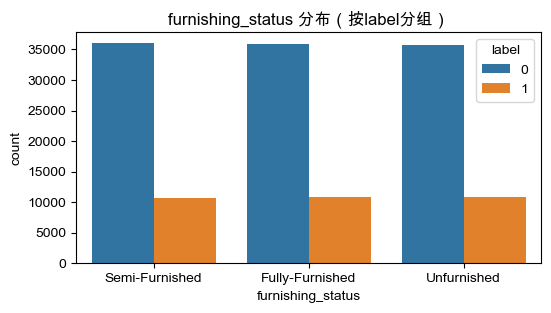

furnishing_status
Fully-Furnished    46869
Semi-Furnished     46623
Unfurnished        46438
Name: count, dtype: int64


In [21]:
# 5. 类别型特征分析
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=df, hue='label')
    plt.title(f'{col} 分布（按label分组）')
    plt.show()
    print(df[col].value_counts())

In [107]:
# 特征工程1: 将类别数据标签化
categorical_features = df.select_dtypes(include=['object']).columns.tolist()

# 创建标签编码器
label_encoders = {}
df_encoded = df.copy()

# 对每个类别型特征进行标签编码
for feature in categorical_features:
    le = LabelEncoder()
    df_encoded[feature + '_encoded'] = le.fit_transform(df[feature])
    label_encoders[feature] = le
    print(f"{feature} -> {feature}_encoded")
    print(f"  原始类别: {df[feature].unique()}")
    print(f"  编码后: {df_encoded[feature + '_encoded'].unique()}")
    print()

# 删除原始类别型特征，保留编码后的特征
df_encoded = df_encoded.drop(columns=categorical_features)
print("标签化后的数据形状:", df_encoded.shape)
print("标签化后的特征类型:")
print(df_encoded.dtypes.value_counts())

#处理 房龄
current_year = 2025
df_encoded['property_age'] = current_year - df_encoded['constructed_year']
df_encoded = df_encoded.drop(columns = ['constructed_year'])

#处理 房价面积比
# log 处理
df_encoded['price_size_ratio'] = np.log(df_encoded['price'] / df_encoded['property_size_sqft'])

#处理 根据购房场景，构造与标签强相关的派生特征：
#affordability_ratio = monthly_expenses / customer_salary
df_encoded['affordability_ratio'] = df_encoded['monthly_expenses'] / df_encoded['customer_salary']

#price_to_salary = price / customer_salary
df_encoded['price_to_salary'] = np.log(df_encoded['price'] / df_encoded['customer_salary'])
# 对price_to_salary 进行监督分箱
df_encoded['price_to_salary'] = pd.cut(df_encoded['price_to_salary'], bins=4, labels=False)

#loan_to_price = loan_amount / price
df_encoded['loan_to_price'] = df_encoded['loan_amount'] / df_encoded['price']

#down_payment_ratio = down_payment / price
df_encoded['down_payment_ratio'] = df_encoded['down_payment'] / df_encoded['price']

#bathrooms_per_room = bathrooms / rooms
df_encoded['bathrooms_per_room'] = df_encoded['bathrooms'] / df_encoded['rooms']


country -> country_encoded
  原始类别: ['South Africa' 'Germany' 'Canada' 'Brazil' 'UAE' 'Australia' 'UK' 'USA'
 'China' 'Singapore' 'India' 'Japan' 'France']
  编码后: [ 9  5  2  1 10  0 11 12  3  8  6  7  4]

property_type -> property_type_encoded
  原始类别: ['Apartment' 'Farmhouse' 'Townhouse' 'Villa' 'Studio' 'Independent House']
  编码后: [0 1 4 5 3 2]

furnishing_status -> furnishing_status_encoded
  原始类别: ['Semi-Furnished' 'Fully-Furnished' 'Unfurnished']
  编码后: [1 0 2]

标签化后的数据形状: (139930, 24)
标签化后的特征类型:
int64      23
float64     1
Name: count, dtype: int64


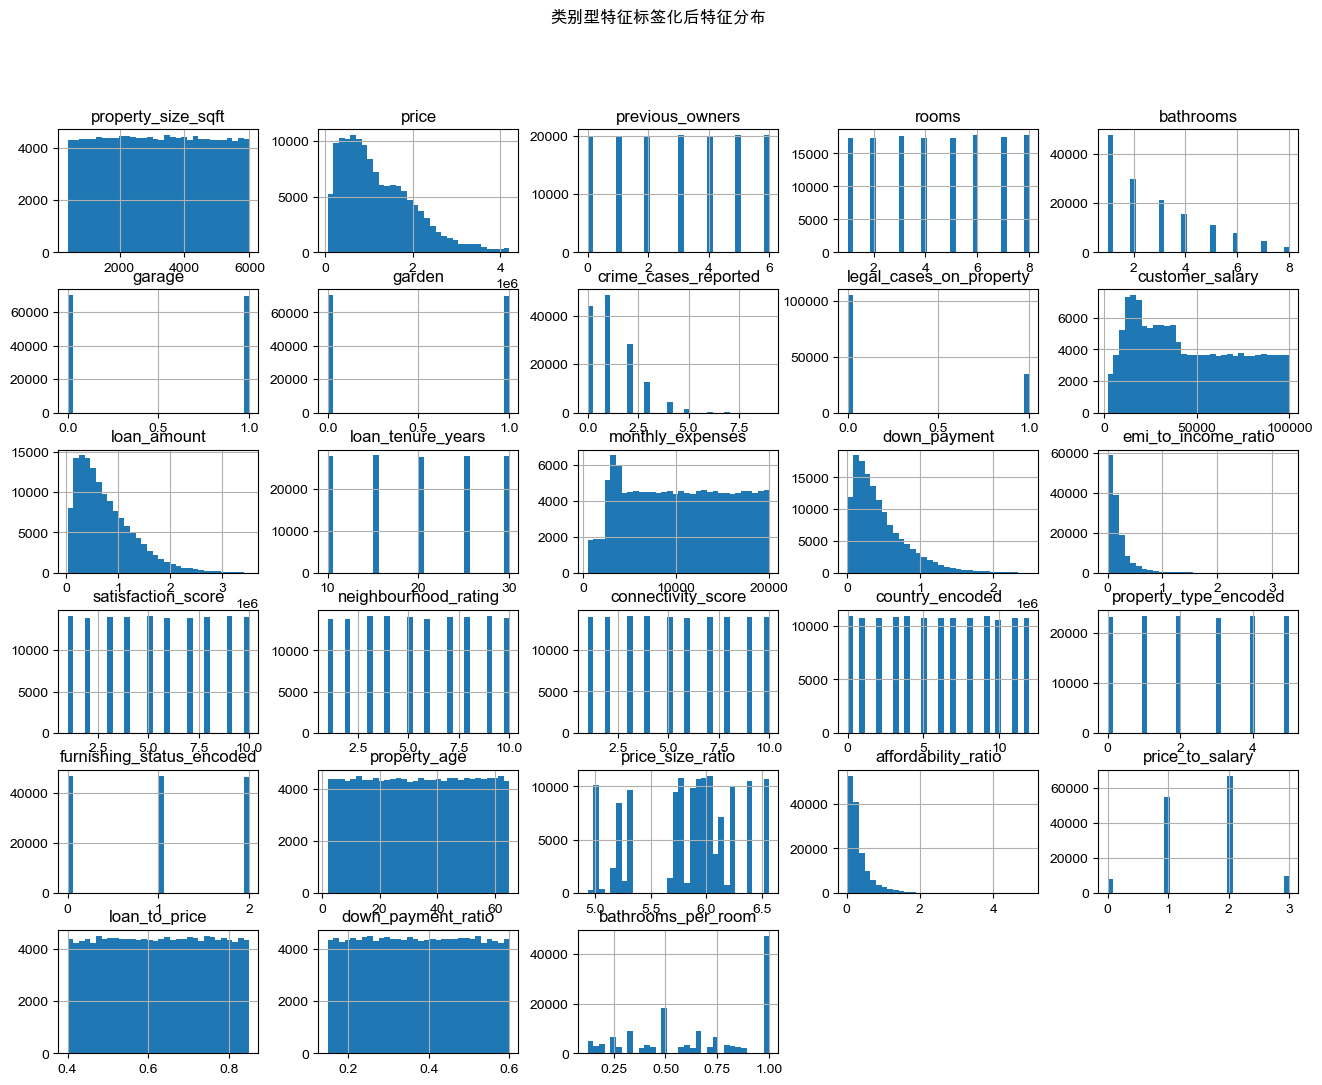

In [111]:
num_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [col for col in num_cols if col not in ['id', 'label']]
df_encoded[num_cols].hist(figsize=(16, 12), bins=32)
plt.suptitle('类别型特征标签化后特征分布')
plt.show() 

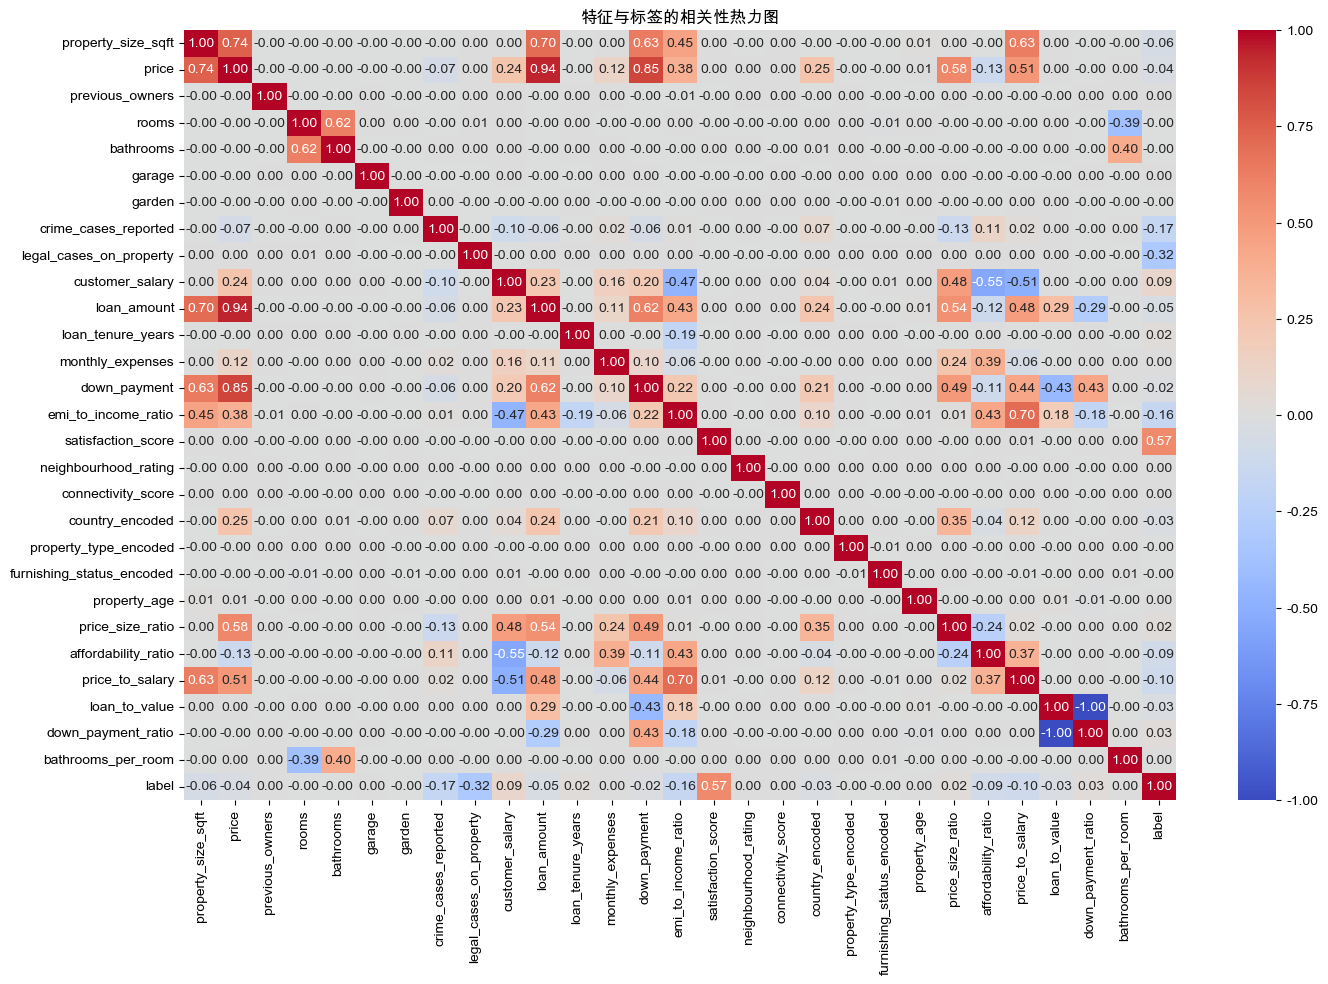

In [105]:
plt.figure(figsize=(16,10))
sns.heatmap(df_encoded[num_cols + ['label']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('特征与标签的相关性热力图')
plt.show()